# House Prices Dataset

link : https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [3]:
print(df.shape)

(1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Feature engineering

In [5]:
# Drop irrelevant columns

df = df.drop(columns=['Id'], errors='ignore')

In [6]:
df.head(1)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


# Handling missing data

In [7]:
# Check missing values count
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
missing_percentage = df.isnull().mean().sort_values(ascending=False)
missing_percentage

# Percentage of TRUE in Total values

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 80, dtype: float64

In [ ]:
# Drop columns with too many missing value

threshold = 0.65
columns_with_high_null_values = missing_percentage[missing_percentage > threshold].index.tolist()

In [10]:
columns_with_high_null_values

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [11]:
df_1 = df.drop(columns=columns_with_high_null_values, errors='ignore')

In [12]:
print(df_1.shape)

(1460, 76)


In [13]:
import numpy as np

In [14]:
# Filter by importance
# (Correlation with salePrice)

target_coorelation = df_1.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()

In [15]:
target_coorelation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [16]:
low_imapct_threshold = 0.1

# Interview Question : coorelation vs covariance
# Always use coorelation

low_impact_cols = target_coorelation[target_coorelation<low_imapct_threshold].index.to_list()
low_impact_cols

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [17]:
df_2 = df_1.drop(columns=low_impact_cols, errors='ignore')

In [18]:
df_2.shape

(1460, 66)

In [32]:
# Removing multi-collinearity

corr_matrix = df_2.select_dtypes(include=[np.number]).corr().abs()

corr_matrix

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,1.000000,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,0.426095,1.000000,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,0.251646,0.105806,1.000000,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,0.123349,0.014228,0.572323,1.000000,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.592855,1.000000,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,0.193458,0.104160,0.411876,0.315707,0.179618,1.000000,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,0.249503,0.128451,0.264736,1.000000,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,0.132644,0.002618,0.308159,0.149040,0.181133,0.114442,0.495251,1.000000,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,0.392075,0.260833,0.537808,0.391452,0.291066,0.363936,0.522396,0.415360,1.000000,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,0.457181,0.299475,0.476224,0.281986,0.240379,0.344501,0.445863,0.317987,0.819530,1.000000,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [33]:
np.triu(np.ones(corr_matrix.shape), k=1)

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],


In [34]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [35]:
# upper

In [36]:
upper.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [37]:
redundant_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print(redundant_cols)

# removing redudant columns

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [41]:
df_3 = df_2.drop(columns=redundant_cols, errors='ignore')

In [43]:
df_3.shape

(1460, 62)

# Part-2

In [57]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

In [45]:
df_3.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [46]:
missing_values = df_3.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

In [47]:
missing_values

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64

In [49]:
temp_df = df_3.dropna() 
temp_df.shape

# Issue, removes too many rows just to have a clean data

(299, 62)

### Simple Imputation

Instead of deleting, we fill the missing values with estimates.

(a) Mean Imputation (Numerical Data)

(b) Median Imputation (Numerical Data)

(c) Mode Imputation (Categorical Data)


In [53]:
# (a) Mean Imputation (Numerical Data)
# LotFrontage
# Pull distribution towards the mean --> underestimates variance.

df_mean = df_3.copy()
df_mean.fillna({"LotFrontage" : df_mean["LotFrontage"].mean()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [56]:
# (a) Median Imputation (Numerical Data)
# LotFrontage
# Robust for outliers

df_median = df_3.copy()
df_median.fillna({"LotFrontage" : df_median["LotFrontage"].median()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [58]:
# (a) Mode Imputation (Cetegorical Data)
# LotFrontage

df_mode = df_3.copy()

In [60]:
df_mode['GarageType'].unique()

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [63]:
df_mode["GarageType"].mode()[0]

'Attchd'

In [64]:
df_mode.fillna({"GarageType" : df_mode["GarageType"].mode()[0]}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


# Compare Before and After Imputation

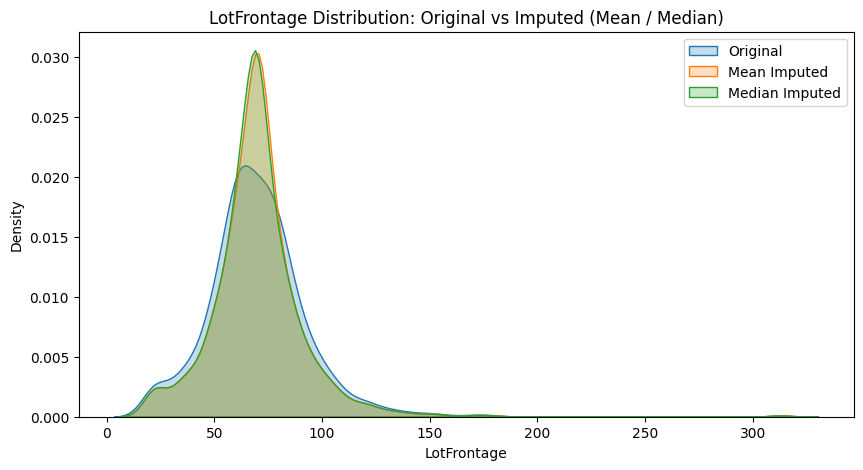

In [65]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()

In [76]:
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

### KNN Imputation

K-nearest neighbour --> ML Algorithm

In [67]:
# !pip install scikit-learn

In [68]:
from sklearn.impute import KNNImputer

In [69]:
knn_imputer = KNNImputer(n_neighbors=5)

In [70]:
df_knn = df_3.copy()

In [71]:
# MasVnrType      872
# FireplaceQu     690
# LotFrontage     259
# GarageType       81
# GarageQual       81
# GarageFinish     81
# GarageCond       81
# BsmtFinType2     38
# BsmtExposure     38
# BsmtQual         37
# BsmtFinType1     37
# BsmtCond         37
# MasVnrArea        8
# Electrical        1

In [72]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols


Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [73]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [82]:
compare_imputation(df_3, df_knn, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,68.4
42,NaN,69.6
43,NaN,70.6
50,NaN,77.8
64,NaN,76.4


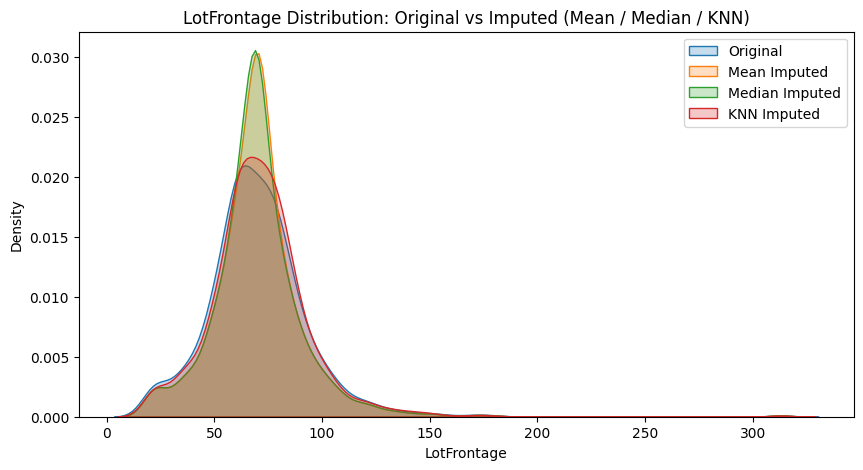

In [87]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

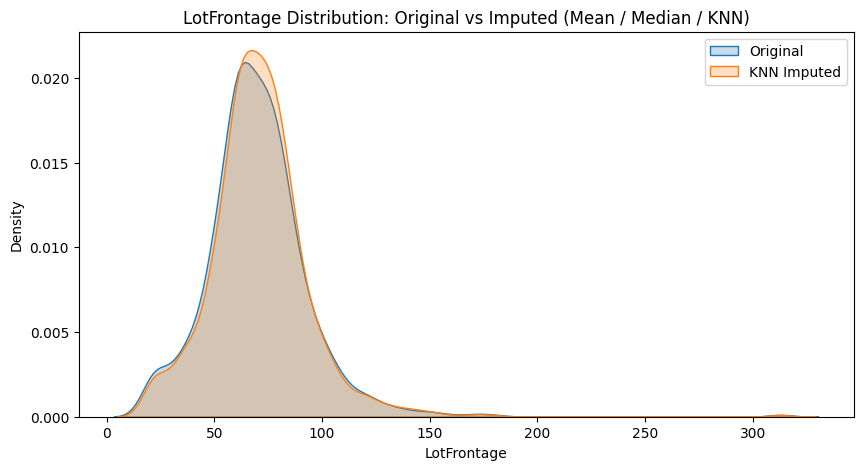

In [88]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
# sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()